<a href="https://colab.research.google.com/github/varshamqa/AutomateBrowserSerVSC-M1/blob/varshamqa-patch-1/AI_ML_RandomForest_Heart_Varsha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [5]:
df=pd.read_csv('/content/heart.csv')

In [6]:
df.shape

(918, 12)

In [7]:
df.head(20)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [8]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [9]:
df.dtypes

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [11]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


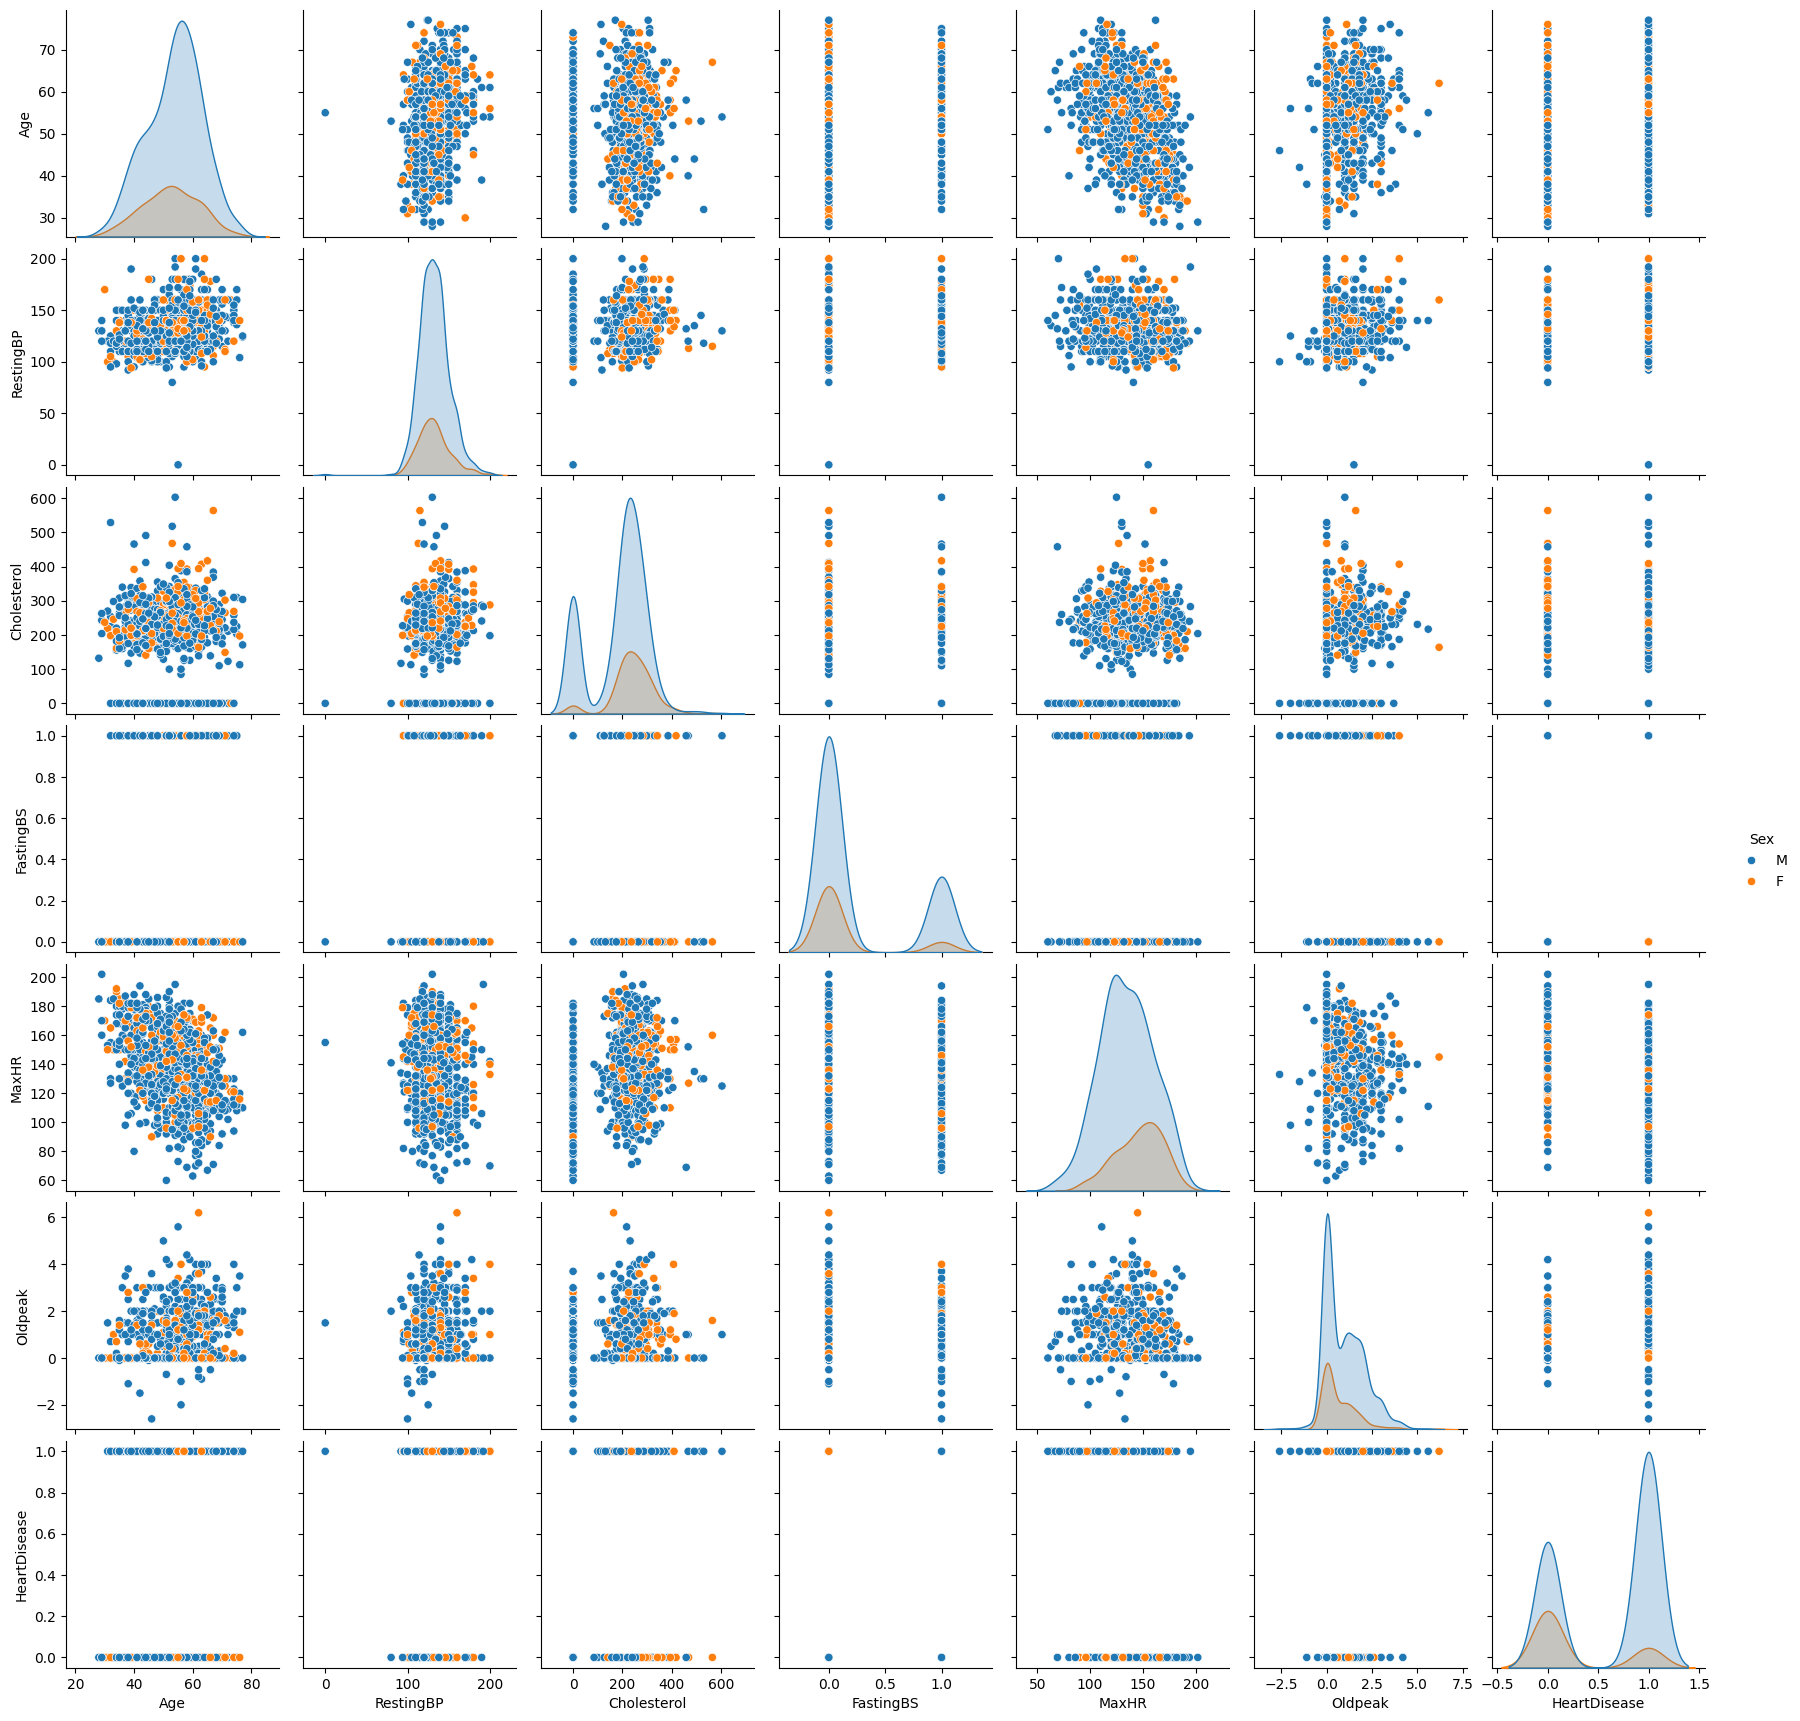

In [14]:
sns.pairplot(data=df, hue='Sex')

/tmp/ipykernel_508/2027693663.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df, x='Sex', y='Age', kind='box',col='HeartDisease', palette='Dark2')


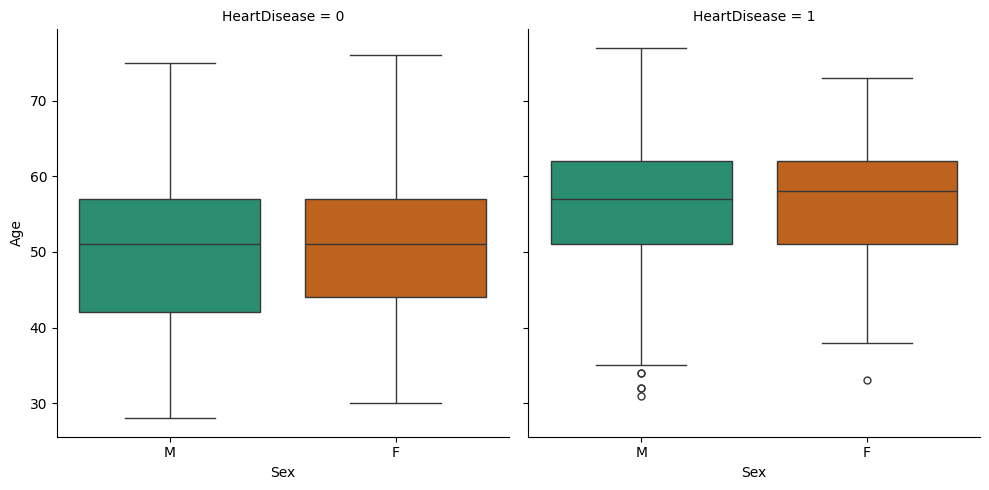

In [17]:
sns.catplot(data=df, x='Sex', y='Age', kind='box',col='HeartDisease', palette='Dark2')

<Axes: xlabel='Sex', ylabel='count'>

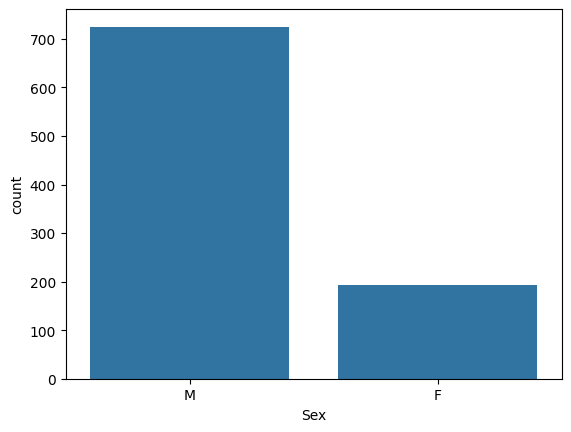

In [18]:
df['Sex'].value_counts()
sns.countplot(data=df, x='Sex')


In [19]:
X=pd.get_dummies(df.drop("Sex", axis=1))
y=df["Sex"]

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [39]:
model=RandomForestClassifier(n_estimators=10 , max_features='log2',random_state=101)

In [40]:
model.fit(X_train,y_train)

RandomForestClassifier(max_features='log2', n_estimators=10, random_state=101)

In [37]:
model=RandomForestClassifier(n_estimators=10 , max_features='sqrt',random_state=101)

In [38]:
model.fit(X_train,y_train)

RandomForestClassifier(n_estimators=10, random_state=101)

In [42]:
y_pred=model.predict(X_test)

In [41]:
from sklearn.metrics import confusion_matrix, classification_report

In [45]:
confusion_matrix(y_pred,y_test)

array([[ 16,  18],
       [ 41, 201]])

In [46]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           F       0.47      0.28      0.35        57
           M       0.83      0.92      0.87       219

    accuracy                           0.79       276
   macro avg       0.65      0.60      0.61       276
weighted avg       0.76      0.79      0.76       276



In [47]:
model.feature_importances_

array([0.14463991, 0.16343135, 0.19635882, 0.02452074, 0.14245991,
       0.08141861, 0.06887557, 0.02494576, 0.01574737, 0.01273138,
       0.00533602, 0.01608179, 0.01653286, 0.01519081, 0.02172276,
       0.01338178, 0.0065622 , 0.01726415, 0.0127982 ])

In [50]:
pd.DataFrame(index= X.columns, data= model.feature_importances_, columns=['Feature Importance'] )

,Feature Importance
Age,0.144640
RestingBP,0.163431
Cholesterol,0.196359
FastingBS,0.024521
MaxHR,0.142460
Oldpeak,0.081419
HeartDisease,0.068876
ChestPainType_ASY,0.024946
ChestPainType_ATA,0.015747
ChestPainType_NAP,0.012731
